# BTUMQA-225K Phase 03C: Clean-Metadata Benchmark Readiness and Bias Audit

This notebook audits the clean-metadata BTUMQA-225K benchmark before final statistical/model claims.

It validates dataset integrity, split hygiene, distribution balance, region uncertainty/area statistics, and forbidden metadata shortcut risk.

Interpretation rule: this notebook improves benchmark transparency. It does not claim the dataset is bias-free.

## 1. Install Required Libraries

In [3]:
import importlib
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])


for import_name, pip_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("sklearn", "scikit-learn"),
]:
    ensure_package(import_name, pip_name)

## 2. Mount Google Drive and Configure Paths

In [6]:
from pathlib import Path
import os
import time

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Updated project path to point to the new drive structure
PROJECT_DRIVE_DIR = Path("/content/drive/MyDrive/AUGR-VQA")

# Corrected input paths: phase_3/p3a_brats_vqa_dataset/dataset_btumqa_225k
DATASET_DIR = PROJECT_DRIVE_DIR / "phase_3" / "p3a_brats_vqa_dataset" / "dataset_btumqa_225k"
BTUMQA_FULL_QA_PATH = DATASET_DIR / "btumqa_225k_qa_pairs.csv"

# Corrected result directory: phase_3/p3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit
RESULT_DIR = PROJECT_DRIVE_DIR / "phase_3" / "p3c_dataset_benchmark_readiness_audit" / "btumqa_225k_clean_metadata_bias_audit"
TABLE_DIR = RESULT_DIR / "tables"
FIG_DIR = RESULT_DIR / "figures"
REPORT_DIR = RESULT_DIR / "reports"
DIAG_DIR = RESULT_DIR / "diagnostics"
DONE_DIR = RESULT_DIR / "done"

for directory in [TABLE_DIR, FIG_DIR, REPORT_DIR, DIAG_DIR, DONE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Dataset:", BTUMQA_FULL_QA_PATH)
print("Output dir:", RESULT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k/btumqa_225k_qa_pairs.csv
Output dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit


## 3. Imports, Helpers, and Metadata Policy

In [7]:
from __future__ import annotations

import hashlib
import json
import math
import os
import platform
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")


def now_string() -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S")


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def save_json(obj: dict, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")
    return path


def save_table(df: pd.DataFrame, path: Path) -> pd.DataFrame:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved {len(df):,} rows -> {path}")
    return df


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else float("nan")


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    table = pd.crosstab(x.fillna("__NA__").astype(str), y.fillna("__NA__").astype(str))
    if table.empty:
        return float("nan")
    obs = table.to_numpy(dtype=float)
    total = obs.sum()
    if total == 0:
        return float("nan")
    row_sum = obs.sum(axis=1, keepdims=True)
    col_sum = obs.sum(axis=0, keepdims=True)
    expected = row_sum @ col_sum / total
    mask = expected > 0
    chi2 = ((obs[mask] - expected[mask]) ** 2 / expected[mask]).sum()
    r, k = obs.shape
    denom = total * max(min(k - 1, r - 1), 1)
    return float(math.sqrt(chi2 / denom))


def normalized_entropy(series: pd.Series) -> float:
    counts = series.fillna("__NA__").astype(str).value_counts(normalize=True)
    if len(counts) <= 1:
        return 0.0
    entropy = -float((counts * np.log2(counts)).sum())
    return entropy / math.log2(len(counts))


def dominance_summary(df: pd.DataFrame, group_col: str, label_col: str = "answer") -> pd.DataFrame:
    rows = []
    for value, sub in df.groupby(group_col, dropna=False):
        label_counts = sub[label_col].fillna("__NA__").astype(str).value_counts()
        top_label = label_counts.index[0] if len(label_counts) else ""
        top_count = int(label_counts.iloc[0]) if len(label_counts) else 0
        rows.append(
            {
                "group_column": group_col,
                "group_value": value,
                "rows": int(len(sub)),
                "unique_answers": int(label_counts.size),
                "top_answer": top_label,
                "top_answer_count": top_count,
                "top_answer_share": safe_div(top_count, len(sub)),
                "answer_entropy_normalized": normalized_entropy(sub[label_col]),
            }
        )
    return pd.DataFrame(rows).sort_values(["top_answer_share", "rows"], ascending=[False, False])


EXPECTED_SPLITS = ["train", "val", "test"]
EXPECTED_ROWS = 225_000
ID_COLUMNS = ["qa_id", "patient_id", "slice_id", "unique_id", "image_id"]
AUDIT_CATEGORICAL_COLUMNS = [
    "answer",
    "answer_type",
    "question_family",
    "question_style",
    "difficulty_level",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_primary",
    "region_target_secondary",
    "decision_rule_id",
    "label_provenance",
    "candidate_keep_reason",
]
REGIONS = ["edema", "ncr_net", "enhancing", "tumor", "context", "global"]
AREA_COLUMNS = [f"{region}_area_pixels" for region in REGIONS]
UNCERTAINTY_COLUMNS = [f"{region}_uncertainty" for region in REGIONS]
WEIGHT_COLUMNS = [f"{region}_weight" for region in REGIONS]
FORBIDDEN_AUDIT_ONLY_COLUMNS = (
    AREA_COLUMNS
    + UNCERTAINTY_COLUMNS
    + WEIGHT_COLUMNS
    + [
        "phase2a_token_file",
        "slice_index_in_token_file",
        "phase2c_file",
        "slice_index_in_ugtm_file",
        "mc_dropout_passes",
        "decision_rule_id",
        "label_provenance",
        "candidate_keep_reason",
    ]
)
CLEAN_SAFE_AUDIT_COLUMNS = [
    "question_family",
    "question_style",
    "difficulty_level",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_primary",
    "region_target_secondary",
]

metadata_policy = pd.DataFrame(
    [
        {
            "column_group": "allowed_clean_model_inputs",
            "columns": "question_embedding | visual_tokens | clean_region_aux_features",
            "policy": "Allowed in clean Phase 4 model training.",
            "interpretation": "No raw answer-proximal metadata is passed as direct model input.",
        },
        {
            "column_group": "clean_safe_audit_descriptors",
            "columns": " | ".join(CLEAN_SAFE_AUDIT_COLUMNS),
            "policy": "Allowed for slicing/auditing and clean-safe shortcut baselines.",
            "interpretation": "Question-visible descriptors reveal benchmark structure but are not raw visual measurement shortcuts.",
        },
        {
            "column_group": "forbidden_audit_only_fields",
            "columns": " | ".join(FORBIDDEN_AUDIT_ONLY_COLUMNS),
            "policy": "Forbidden as final answer model inputs; audit-only for leakage/shortcut risk measurement.",
            "interpretation": "These can expose label-construction or answer-proximal information and must be clearly separated.",
        },
    ]
)
save_table(metadata_policy, TABLE_DIR / "phase03c_clean_metadata_policy_columns.csv")
metadata_policy

Saved 3 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/tables/phase03c_clean_metadata_policy_columns.csv


,column_group,columns,policy,interpretation
0,allowed_clean_model_inputs,question_embedding | visual_tokens | clean_reg...,Allowed in clean Phase 4 model training.,No raw answer-proximal metadata is passed as d...
1,clean_safe_audit_descriptors,question_family | question_style | difficulty_...,Allowed for slicing/auditing and clean-safe sh...,Question-visible descriptors reveal benchmark ...
2,forbidden_audit_only_fields,edema_area_pixels | ncr_net_area_pixels | enha...,Forbidden as final answer model inputs; audit-...,These can expose label-construction or answer-...


## 4. Load Dataset and Reproducibility Manifest

In [8]:
if not BTUMQA_FULL_QA_PATH.exists():
    raise FileNotFoundError(f"BTUMQA CSV not found: {BTUMQA_FULL_QA_PATH}")

dtype_cols = {col: str for col in ["qa_id", "patient_id", "slice_id", "unique_id", "image_id"]}
df = pd.read_csv(BTUMQA_FULL_QA_PATH, dtype=dtype_cols)

manifest = {
    "phase": "Phase 03C clean-metadata benchmark readiness and bias audit",
    "created_at": now_string(),
    "dataset_path": str(BTUMQA_FULL_QA_PATH),
    "dataset_sha256": sha256_file(BTUMQA_FULL_QA_PATH),
    "rows": int(len(df)),
    "columns": list(df.columns),
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "output_dir": str(RESULT_DIR),
}
save_json(manifest, REPORT_DIR / "phase03c_clean_metadata_reproducibility_manifest.json")

print(f"Loaded BTUMQA rows: {len(df):,}")
display(df.head())

Loaded BTUMQA rows: 225,000


,qa_id,split,patient_id,slice_id,unique_id,image_id,question,answer,answer_type,question_family,template_id,paraphrase_id,dataset_branch,question_style,difficulty_level,ambiguity_flag,region_target_primary,region_target_secondary,signal_gap_bucket,decision_rule_id,label_provenance,candidate_keep_reason,modality_context,tumor_slice_csv,edema_area_pixels,ncr_net_area_pixels,enhancing_area_pixels,tumor_area_pixels,context_area_pixels,global_area_pixels,edema_uncertainty,ncr_net_uncertainty,enhancing_uncertainty,tumor_uncertainty,context_uncertainty,global_uncertainty,edema_weight,ncr_net_weight,enhancing_weight,tumor_weight,context_weight,global_weight,phase2a_token_file,slice_index_in_token_file,phase2c_file,slice_index_in_ugtm_file,mc_dropout_passes
0,BTUMQA225K_07a3eda3b59c63,test,00002,033,00002_033,033,"Is edema confidently present, uncertainly pres...",not_present,classification,confidence_qualified_presence,confidence_qualified_presence_template_02,confidence_qualified_presence_paraphrase_02,btumqa_225k,confidence_qualified,easy,no,edema,NaN,wide_gap,confidence_qualified_presence_v1,phase1_pseudo_mask+phase2b_uncertainty,balanced_family_sampling,FLAIR|T1|T1ce|T2,0,0,0,0,0,0,5663,0.0,0.0,0.0,0.0,0.0,2.300000e-07,1.0,1.0,1.0,1.0,1.0,1.000000,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,20
1,BTUMQA225K_668ac232b10861,test,00002,033,00002_033,033,Which region is safest to trust for reasoning ...,global,classification,safe_region_for_reasoning,safe_region_for_reasoning_template_01,safe_region_for_reasoning_paraphrase_01,btumqa_225k,ranking,easy,no,global,NaN,wide_gap,safe_region_for_reasoning_v1,phase2a_area+phase2c_weight,balanced_family_sampling,FLAIR|T1|T1ce|T2,0,0,0,0,0,0,5663,0.0,0.0,0.0,0.0,0.0,2.300000e-07,1.0,1.0,1.0,1.0,1.0,1.000000,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,20
2,BTUMQA225K_f1d4b092590518,test,00002,033,00002_033,033,Which confidence-qualified extent label best f...,none,classification,confidence_qualified_extent,confidence_qualified_extent_template_03,confidence_qualified_extent_paraphrase_03,btumqa_225k,confidence_qualified,easy,no,tumor,NaN,wide_gap,confidence_qualified_extent_v1,phase1_pseudo_mask+phase2b_uncertainty,balanced_family_sampling,FLAIR|T1|T1ce|T2,0,0,0,0,0,0,5663,0.0,0.0,0.0,0.0,0.0,2.300000e-07,1.0,1.0,1.0,1.0,1.0,1.000000,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,20
3,BTUMQA225K_c2e575cfe72f68,test,00002,034,00002_034,034,Which region should receive the highest trust ...,global,classification,safe_region_for_reasoning,safe_region_for_reasoning_template_03,safe_region_for_reasoning_paraphrase_03,btumqa_225k,ranking,easy,no,global,NaN,wide_gap,safe_region_for_reasoning_v1,phase2a_area+phase2c_weight,balanced_family_sampling,FLAIR|T1|T1ce|T2,0,0,0,0,0,0,6109,0.0,0.0,0.0,0.0,0.0,6.800000e-07,1.0,1.0,1.0,1.0,1.0,0.999999,/content/drive/MyDrive/AMIR Lab/Research Assis...,1,/content/drive/MyDrive/AMIR Lab/Research Assis...,1,20
4,BTUMQA225K_142f3c4ec5e345,test,00002,035,00002_035,035,"Is edema confidently present, uncertainly pres...",not_present,classification,confidence_qualified_presence,confidence_qualified_presence_template_02,confidence_qualified_presence_paraphrase_02,btumqa_225k,confidence_qualified,easy,no,edema,NaN,wide_gap,confidence_qualified_presence_v1,phase1_pseudo_mask+phase2b_uncertainty,balanced_family_sampling,FLAIR|T1|T1ce|T2,0,0,0,0,0,0,6444,0.0,0.0,0.0,0.0,0.0,7.400000e-07,1.0,1.0,1.0,1.0,1.0,0.999999,/content/drive/MyDrive/AMIR Lab/Research Assis...,2,/content/drive/MyDrive/AMIR Lab/Research Assis...,2,20


## 5. Integrity, Missingness, Duplicate, and Split-Leakage Checks

In [9]:
required_columns = sorted(set(ID_COLUMNS + ["split", "question", "answer"] + AUDIT_CATEGORICAL_COLUMNS + FORBIDDEN_AUDIT_ONLY_COLUMNS))
schema_rows = []
for col in required_columns:
    schema_rows.append(
        {
            "column": col,
            "present": col in df.columns,
            "missing_count": int(df[col].isna().sum()) if col in df.columns else None,
            "missing_rate": float(df[col].isna().mean()) if col in df.columns else None,
            "unique_values": int(df[col].nunique(dropna=True)) if col in df.columns else None,
        }
    )
schema_table = save_table(pd.DataFrame(schema_rows), TABLE_DIR / "phase03c_clean_schema_missingness.csv")

integrity_rows = [
    {"check": "expected_row_count_225000", "value": int(len(df)), "passed": bool(len(df) == EXPECTED_ROWS)},
    {"check": "qa_id_unique", "value": int(df["qa_id"].nunique()), "passed": bool(df["qa_id"].is_unique)},
    {"check": "no_missing_split", "value": int(df["split"].isna().sum()), "passed": bool(df["split"].notna().all())},
    {"check": "known_splits_only", "value": "|".join(sorted(df["split"].dropna().astype(str).unique())), "passed": bool(set(df["split"].dropna().astype(str)).issubset(EXPECTED_SPLITS))},
    {"check": "no_missing_question", "value": int(df["question"].isna().sum()), "passed": bool(df["question"].notna().all())},
    {"check": "no_missing_answer", "value": int(df["answer"].isna().sum()), "passed": bool(df["answer"].notna().all())},
]
duplicate_subset = ["split", "patient_id", "slice_id", "question", "answer"]
integrity_rows.append(
    {
        "check": "duplicate_question_answer_rows_within_split",
        "value": int(df.duplicated(subset=duplicate_subset).sum()),
        "passed": bool(df.duplicated(subset=duplicate_subset).sum() == 0),
    }
)
integrity_table = save_table(pd.DataFrame(integrity_rows), TABLE_DIR / "phase03c_clean_integrity_checks.csv")

leakage_rows = []
for col in ["qa_id", "patient_id", "unique_id"]:
    split_sets = {split: set(df.loc[df["split"] == split, col].dropna().astype(str)) for split in EXPECTED_SPLITS}
    for i, left in enumerate(EXPECTED_SPLITS):
        for right in EXPECTED_SPLITS[i + 1 :]:
            overlap = split_sets[left] & split_sets[right]
            leakage_rows.append(
                {
                    "unit": col,
                    "split_pair": f"{left}_vs_{right}",
                    "left_units": len(split_sets[left]),
                    "right_units": len(split_sets[right]),
                    "overlap_units": len(overlap),
                    "passed_no_overlap": len(overlap) == 0,
                }
            )
leakage_table = save_table(pd.DataFrame(leakage_rows), TABLE_DIR / "phase03c_clean_split_leakage_checks.csv")

display(integrity_table)
display(leakage_table)

Saved 42 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/tables/phase03c_clean_schema_missingness.csv
Saved 7 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/tables/phase03c_clean_integrity_checks.csv
Saved 9 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/tables/phase03c_clean_split_leakage_checks.csv


,check,value,passed
0,expected_row_count_225000,225000,True
1,qa_id_unique,225000,True
2,no_missing_split,0,True
3,known_splits_only,test|train|val,True
4,no_missing_question,0,True
5,no_missing_answer,0,True
6,duplicate_question_answer_rows_within_split,0,True


,unit,split_pair,left_units,right_units,overlap_units,passed_no_overlap
0,qa_id,train_vs_val,157500,33750,0,True
1,qa_id,train_vs_test,157500,33750,0,True
2,qa_id,val_vs_test,33750,33750,0,True
3,patient_id,train_vs_val,876,188,0,True
4,patient_id,train_vs_test,876,187,0,True
5,patient_id,val_vs_test,188,187,0,True
6,unique_id,train_vs_val,50481,10615,0,True
7,unique_id,train_vs_test,50481,10929,0,True
8,unique_id,val_vs_test,10615,10929,0,True


## 6. Distribution, Skew, and Concentration Audit

In [10]:
distribution_frames = []
for col in [c for c in AUDIT_CATEGORICAL_COLUMNS if c in df.columns]:
    counts = df[col].fillna("__NA__").astype(str).value_counts().rename_axis("value").reset_index(name="count")
    counts["column"] = col
    counts["share"] = counts["count"] / len(df)
    distribution_frames.append(counts[["column", "value", "count", "share"]])
distribution_table = save_table(pd.concat(distribution_frames, ignore_index=True), TABLE_DIR / "phase03c_clean_distribution_counts.csv")

dominance_tables = []
for col in ["question_family", "question_style", "difficulty_level", "ambiguity_flag", "signal_gap_bucket", "region_target_primary", "region_target_secondary", "patient_id", "unique_id"]:
    if col in df.columns:
        dom = dominance_summary(df, col, "answer")
        dominance_tables.append(dom)
dominance_table = save_table(pd.concat(dominance_tables, ignore_index=True), TABLE_DIR / "phase03c_clean_answer_dominance_by_group.csv")

concentration_rows = []
for split, sub in df.groupby("split"):
    for unit in ["patient_id", "unique_id"]:
        counts = sub[unit].astype(str).value_counts()
        concentration_rows.append(
            {
                "split": split,
                "unit": unit,
                "unique_units": int(counts.size),
                "rows": int(len(sub)),
                "mean_rows_per_unit": float(counts.mean()),
                "median_rows_per_unit": float(counts.median()),
                "max_rows_per_unit": int(counts.max()),
                "top_1pct_row_share": float(counts.head(max(1, math.ceil(0.01 * len(counts)))).sum() / len(sub)),
                "top_5pct_row_share": float(counts.head(max(1, math.ceil(0.05 * len(counts)))).sum() / len(sub)),
            }
        )
concentration_table = save_table(pd.DataFrame(concentration_rows), TABLE_DIR / "phase03c_clean_patient_slice_concentration.csv")

display(distribution_table.head(20))
display(dominance_table.head(20))
display(concentration_table)

Saved 81 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/tables/phase03c_clean_distribution_counts.csv
Saved 73,313 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/tables/phase03c_clean_answer_dominance_by_group.csv
Saved 6 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/tables/phase03c_clean_patient_slice_concentration.csv


,column,value,count,share
0,answer,edema,24390,0.108400
1,answer,enhancing,23014,0.102284
2,answer,close_gap,22494,0.099973
3,answer,context,21313,0.094724
4,answer,consistent,20556,0.091360
5,answer,ncr_net,19661,0.087382
6,answer,tumor,18565,0.082511
7,answer,distinct,17968,0.079858
8,answer,moderate_gap,10652,0.047342
9,answer,confident_present,5630,0.025022


,group_column,group_value,rows,unique_answers,top_answer,top_answer_count,top_answer_share,answer_entropy_normalized
0,question_family,uncertainty_consistency_check,22499,2,consistent,20556,0.913641,0.424200
1,question_family,ambiguous_subregion_pair,22501,2,distinct,17968,0.798542,0.724834
2,question_family,reliability_gap_bucket,18000,3,close_gap,11465,0.636944,0.762553
3,question_family,uncertainty_gap_bucket,18000,3,close_gap,11029,0.612722,0.793430
4,question_family,safe_region_for_reasoning,18000,4,tumor,8557,0.475389,0.720139
5,question_family,dominant_region_under_uncertainty,22500,3,edema,10459,0.464844,0.948880
6,question_family,confidence_qualified_presence,16875,3,confident_present,5630,0.333630,1.000000
7,question_family,lowest_risk_region,16875,5,context,5049,0.299200,0.909514
8,question_family,highest_risk_region,16875,6,ncr_net,4470,0.264889,0.925883
9,question_family,more_reliable_region,18000,5,tumor,3802,0.211222,0.999574


,split,unit,unique_units,rows,mean_rows_per_unit,median_rows_per_unit,max_rows_per_unit,top_1pct_row_share,top_5pct_row_share
0,test,patient_id,187,33750,180.481283,186.0,235,0.013926,0.069630
1,test,unique_id,10929,33750,3.088114,3.0,12,0.028859,0.120889
2,train,patient_id,876,157500,179.794521,189.0,234,0.013371,0.065371
3,train,unique_id,50481,157500,3.119986,3.0,13,0.029117,0.121371
4,val,patient_id,188,33750,179.521277,183.0,234,0.013867,0.069333
5,val,unique_id,10615,33750,3.179463,3.0,12,0.029274,0.121333


## 7. Region Area, Uncertainty, Weight, and Split-Drift Audit

In [11]:
region_rows = []
for region in REGIONS:
    area_col = f"{region}_area_pixels"
    uncertainty_col = f"{region}_uncertainty"
    weight_col = f"{region}_weight"
    if not all(col in df.columns for col in [area_col, uncertainty_col, weight_col]):
        continue
    for split, sub in df.groupby("split"):
        region_rows.append(
            {
                "region": region,
                "split": split,
                "rows": int(len(sub)),
                "area_mean": float(pd.to_numeric(sub[area_col], errors="coerce").mean()),
                "area_median": float(pd.to_numeric(sub[area_col], errors="coerce").median()),
                "area_zero_share": float((pd.to_numeric(sub[area_col], errors="coerce").fillna(0) == 0).mean()),
                "uncertainty_mean": float(pd.to_numeric(sub[uncertainty_col], errors="coerce").mean()),
                "uncertainty_median": float(pd.to_numeric(sub[uncertainty_col], errors="coerce").median()),
                "weight_mean": float(pd.to_numeric(sub[weight_col], errors="coerce").mean()),
                "weight_median": float(pd.to_numeric(sub[weight_col], errors="coerce").median()),
            }
        )
region_table = save_table(pd.DataFrame(region_rows), TABLE_DIR / "phase03c_clean_region_area_uncertainty_weight_summary.csv")

split_drift_rows = []
for col in [c for c in AUDIT_CATEGORICAL_COLUMNS if c in df.columns]:
    full_dist = df[col].fillna("__NA__").astype(str).value_counts(normalize=True)
    for split, sub in df.groupby("split"):
        split_dist = sub[col].fillna("__NA__").astype(str).value_counts(normalize=True)
        values = sorted(set(full_dist.index) | set(split_dist.index))
        total_variation = 0.5 * sum(abs(float(split_dist.get(v, 0.0)) - float(full_dist.get(v, 0.0))) for v in values)
        split_drift_rows.append(
            {
                "column": col,
                "split": split,
                "total_variation_from_full": float(total_variation),
                "split_top_value": split_dist.index[0] if len(split_dist) else "",
                "split_top_share": float(split_dist.iloc[0]) if len(split_dist) else float("nan"),
                "full_top_value": full_dist.index[0] if len(full_dist) else "",
                "full_top_share": float(full_dist.iloc[0]) if len(full_dist) else float("nan"),
            }
        )
split_drift_table = save_table(pd.DataFrame(split_drift_rows), TABLE_DIR / "phase03c_clean_split_distribution_drift.csv")

display(region_table.head(18))
display(split_drift_table.sort_values("total_variation_from_full", ascending=False).head(20))

Saved 18 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/tables/phase03c_clean_region_area_uncertainty_weight_summary.csv
Saved 36 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/tables/phase03c_clean_split_distribution_drift.csv


,region,split,rows,area_mean,area_median,area_zero_share,uncertainty_mean,uncertainty_median,weight_mean,weight_median
0,edema,test,33750,944.624059,848.0,0.035407,0.020254,0.012924,0.979746,0.987076
1,edema,train,157500,965.886165,793.0,0.033225,0.020102,0.012525,0.979898,0.987475
2,edema,val,33750,964.290341,797.0,0.032681,0.021438,0.012734,0.978562,0.987266
3,ncr_net,test,33750,385.233837,164.0,0.159733,0.031651,0.012515,0.968349,0.987485
4,ncr_net,train,157500,390.643924,172.0,0.161048,0.029131,0.011861,0.970869,0.988139
5,ncr_net,val,33750,373.482933,142.0,0.158163,0.031600,0.013516,0.968400,0.986484
6,enhancing,test,33750,411.952652,295.0,0.186133,0.027165,0.006298,0.972835,0.993702
7,enhancing,train,157500,410.881841,319.0,0.181829,0.026267,0.006007,0.973733,0.993993
8,enhancing,val,33750,396.267052,300.0,0.178815,0.026032,0.006045,0.973968,0.993955
9,tumor,test,33750,1741.810548,1689.0,0.032237,0.020799,0.011101,0.979201,0.988899


,column,split,total_variation_from_full,split_top_value,split_top_share,full_top_value,full_top_share
35,candidate_keep_reason,val,0.029859,balanced_family_sampling,0.561037,balanced_family_sampling,0.531178
33,candidate_keep_reason,test,0.028378,balanced_family_sampling,0.559556,balanced_family_sampling,0.531178
14,difficulty_level,val,0.016646,medium,0.416178,medium,0.411560
17,ambiguity_flag,val,0.016627,no,0.673778,no,0.657151
20,signal_gap_bucket,val,0.016627,moderate_gap,0.416119,moderate_gap,0.411520
2,answer,val,0.016215,edema,0.109748,edema,0.108400
26,region_target_secondary,val,0.013764,enhancing,0.223141,enhancing,0.211093
34,candidate_keep_reason,train,0.012479,balanced_family_sampling,0.518698,balanced_family_sampling,0.531178
0,answer,test,0.010612,edema,0.108830,edema,0.108400
21,region_target_primary,test,0.010600,edema,0.371941,edema,0.380751


## 8. Metadata Shortcut-Risk Association Audit

In [13]:
shortcut_rows = []

for col in [c for c in CLEAN_SAFE_AUDIT_COLUMNS + FORBIDDEN_AUDIT_ONLY_COLUMNS if c in df.columns]:
    series = df[col]

    if (
        pd.api.types.is_numeric_dtype(series)
        or col in AREA_COLUMNS + UNCERTAINTY_COLUMNS + WEIGHT_COLUMNS
        or col in ["mc_dropout_passes", "slice_index_in_token_file", "slice_index_in_ugtm_file"]
    ):
        ranked = pd.to_numeric(series, errors="coerce").rank(method="first")
        binned_raw = pd.qcut(ranked, q=10, duplicates="drop")
        binned = binned_raw.astype(str).replace("nan", "__NA__")
        feature_kind = "numeric_binned"
    else:
        binned = series.fillna("__NA__").astype(str)
        feature_kind = "categorical"

    binned_series = pd.Series(binned, index=df.index).fillna("__NA__").astype(str)

    grouped_entropy = (
        df.assign(_feature=binned_series)
        .groupby("_feature")["answer"]
        .apply(normalized_entropy)
        .mean()
    )

    shortcut_rows.append(
        {
            "column": col,
            "policy_group": "clean_safe_audit_descriptor"
            if col in CLEAN_SAFE_AUDIT_COLUMNS
            else "forbidden_audit_only",
            "feature_kind": feature_kind,
            "unique_values": int(series.nunique(dropna=True)),
            "answer_cramers_v": cramers_v(binned_series, df["answer"]),
            "answer_entropy_after_group_mean": float(grouped_entropy),
        }
    )

shortcut_table = save_table(
    pd.DataFrame(shortcut_rows).sort_values("answer_cramers_v", ascending=False),
    TABLE_DIR / "phase03c_clean_metadata_answer_association_shortcut_risk.csv",
)

display(shortcut_table.head(30))


Saved 33 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/tables/phase03c_clean_metadata_answer_association_shortcut_risk.csv


,column,policy_group,feature_kind,unique_values,answer_cramers_v,answer_entropy_after_group_mean
1,question_style,clean_safe_audit_descriptor,categorical,5,0.816090,0.914352
32,candidate_keep_reason,forbidden_audit_only,categorical,3,0.799194,0.609358
5,region_target_primary,clean_safe_audit_descriptor,categorical,6,0.796200,0.526934
3,ambiguity_flag,clean_safe_audit_descriptor,categorical,2,0.741733,0.900816
0,question_family,clean_safe_audit_descriptor,categorical,12,0.706805,0.850596
30,decision_rule_id,forbidden_audit_only,categorical,12,0.706805,0.850596
4,signal_gap_bucket,clean_safe_audit_descriptor,categorical,3,0.678411,0.923232
2,difficulty_level,clean_safe_audit_descriptor,categorical,3,0.678409,0.923232
6,region_target_secondary,clean_safe_audit_descriptor,categorical,5,0.583784,0.883394
31,label_provenance,forbidden_audit_only,categorical,5,0.570335,0.874024


## 9. Reviewer-Friendly Figures

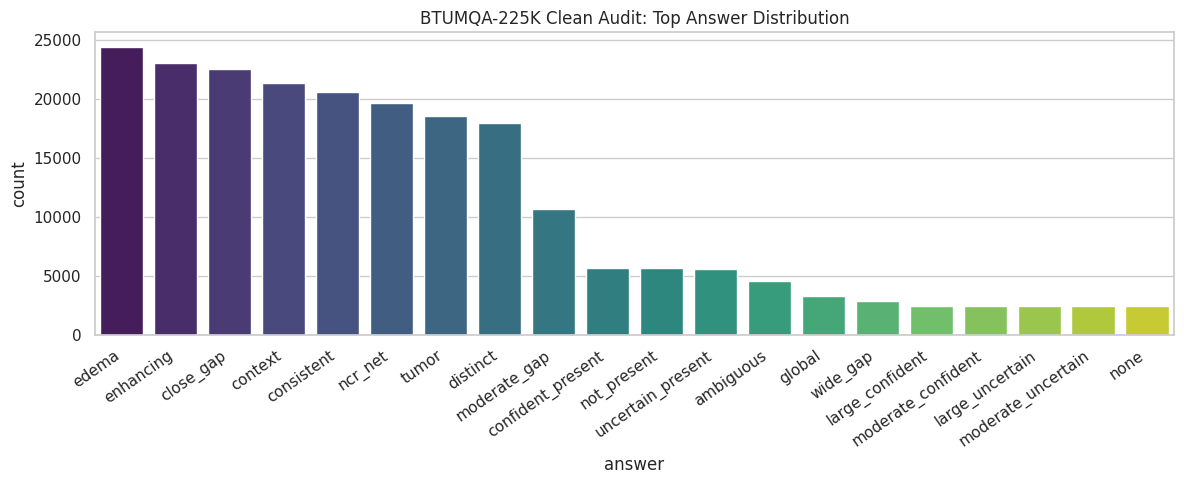

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/figures/phase03c_clean_top_answer_distribution.png


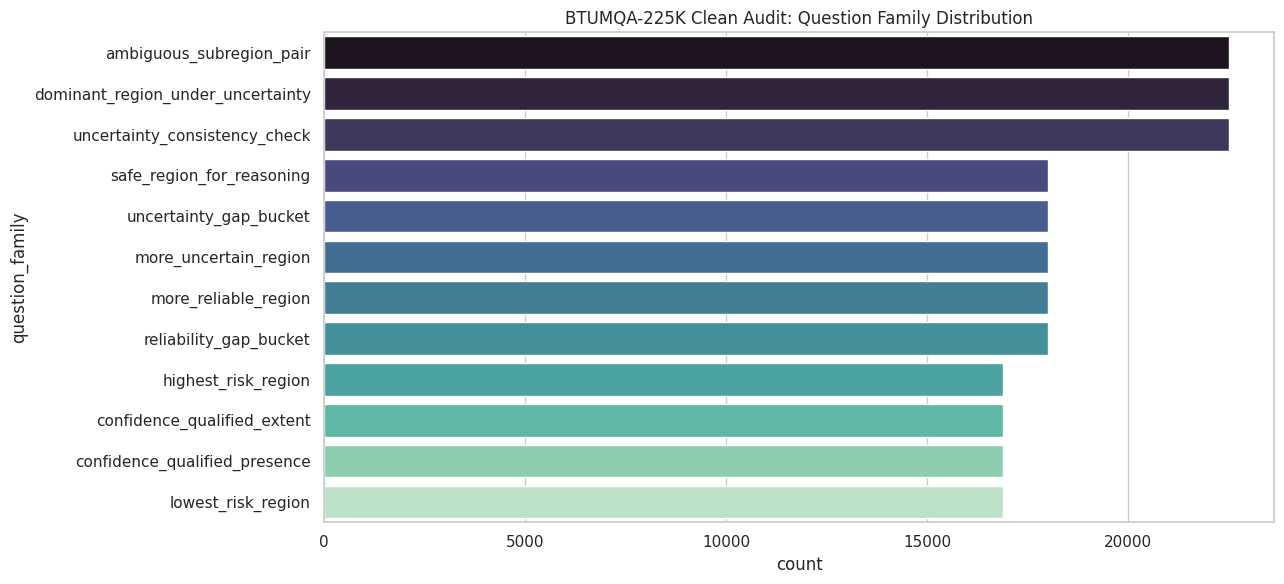

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/figures/phase03c_clean_question_family_distribution.png


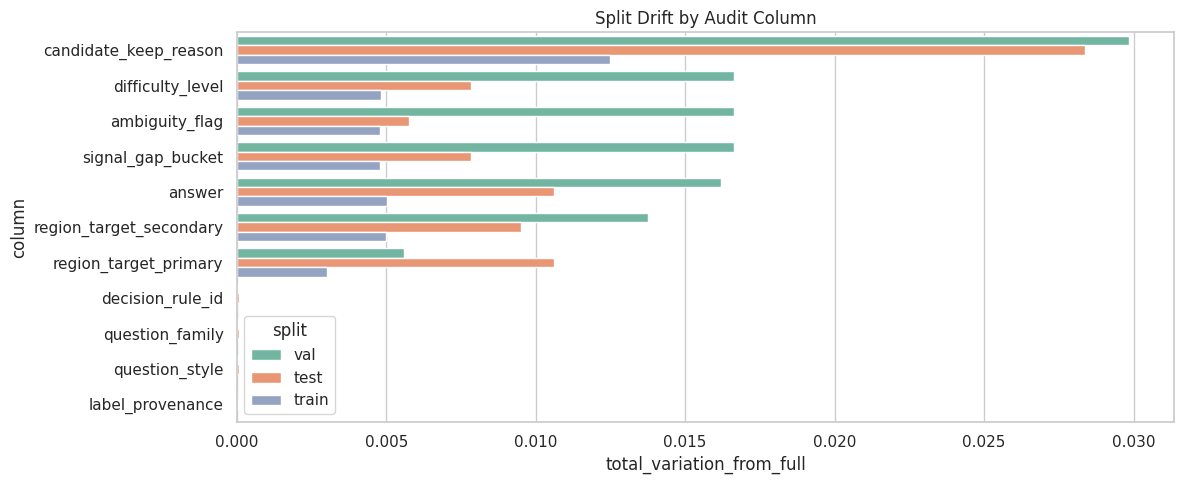

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/figures/phase03c_clean_split_drift_top_columns.png


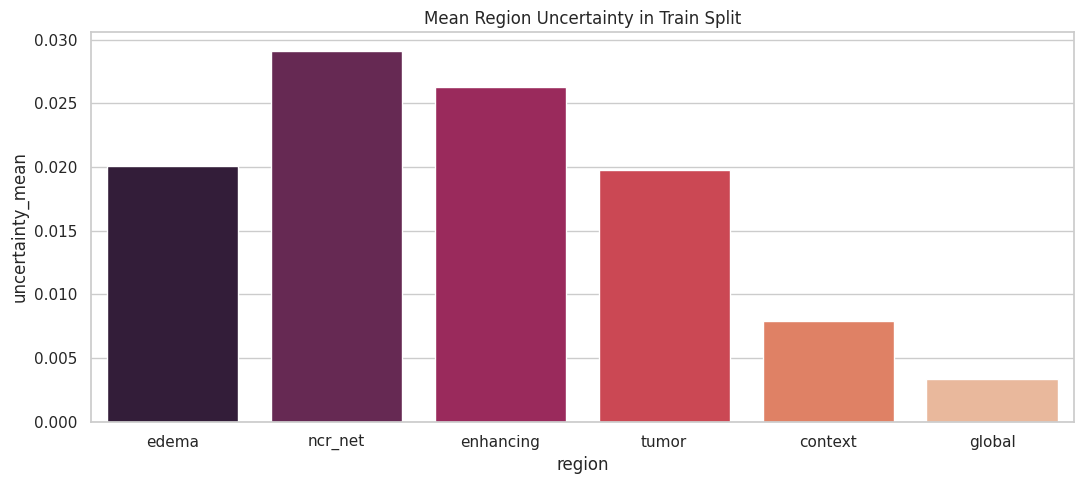

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/figures/phase03c_clean_region_uncertainty_train.png


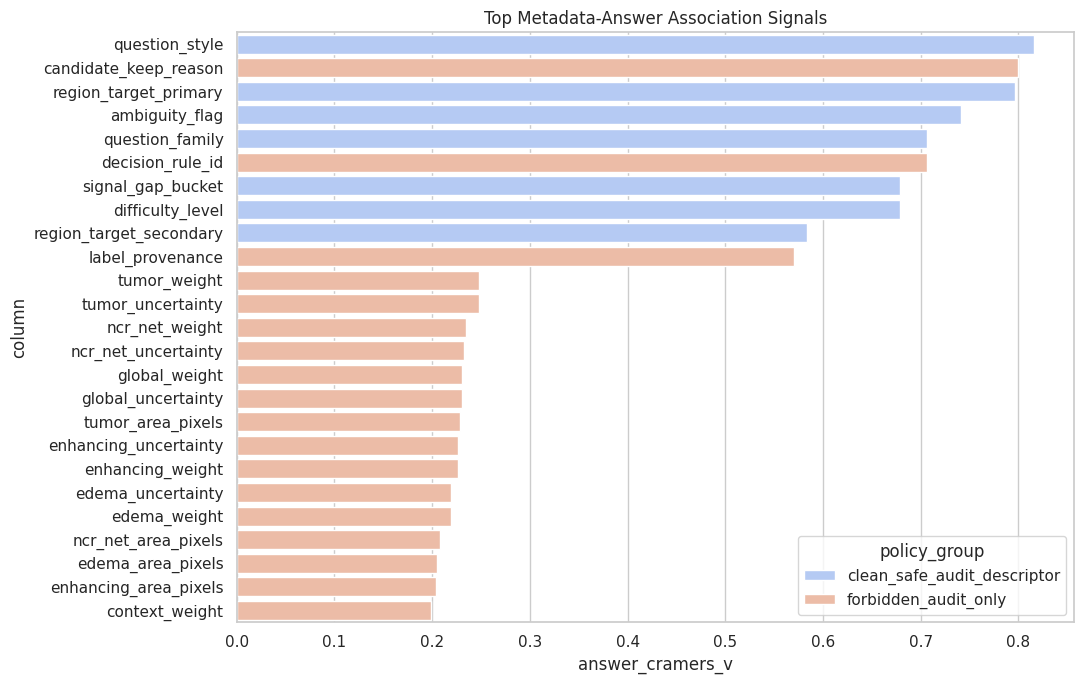

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/figures/phase03c_clean_shortcut_risk_associations.png


PosixPath('/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit/figures/phase03c_clean_shortcut_risk_associations.png')

In [14]:
def save_current_figure(name: str) -> Path:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)
    return path


top_answers = df["answer"].astype(str).value_counts().head(20).reset_index()
top_answers.columns = ["answer", "count"]
plt.figure(figsize=(12, 5))
sns.barplot(data=top_answers, x="answer", y="count", hue="answer", dodge=False, legend=False, palette="viridis")
plt.xticks(rotation=35, ha="right")
plt.title("BTUMQA-225K Clean Audit: Top Answer Distribution")
save_current_figure("phase03c_clean_top_answer_distribution.png")

family_counts = df["question_family"].astype(str).value_counts().reset_index()
family_counts.columns = ["question_family", "count"]
plt.figure(figsize=(13, 6))
sns.barplot(data=family_counts, y="question_family", x="count", hue="question_family", dodge=False, legend=False, palette="mako")
plt.title("BTUMQA-225K Clean Audit: Question Family Distribution")
save_current_figure("phase03c_clean_question_family_distribution.png")

plt.figure(figsize=(12, 5))
plot_df = split_drift_table.sort_values("total_variation_from_full", ascending=False).head(30)
sns.barplot(data=plot_df, x="total_variation_from_full", y="column", hue="split", palette="Set2")
plt.title("Split Drift by Audit Column")
save_current_figure("phase03c_clean_split_drift_top_columns.png")

plt.figure(figsize=(11, 5))
unc_plot = region_table[region_table["split"] == "train"].copy()
sns.barplot(data=unc_plot, x="region", y="uncertainty_mean", hue="region", dodge=False, legend=False, palette="rocket")
plt.title("Mean Region Uncertainty in Train Split")
save_current_figure("phase03c_clean_region_uncertainty_train.png")

plt.figure(figsize=(11, 7))
shortcut_plot = shortcut_table.head(25).copy()
sns.barplot(data=shortcut_plot, x="answer_cramers_v", y="column", hue="policy_group", dodge=False, palette="coolwarm")
plt.title("Top Metadata-Answer Association Signals")
save_current_figure("phase03c_clean_shortcut_risk_associations.png")

## 10. Final Report and Done Marker

In [15]:
high_shortcut = shortcut_table.query("policy_group == 'forbidden_audit_only'").head(10)
clean_safe_shortcut = shortcut_table.query("policy_group == 'clean_safe_audit_descriptor'").head(10)

report = {
    "finished_at": now_string(),
    "phase": "Phase 03C clean-metadata benchmark readiness and bias audit",
    "dataset_rows": int(len(df)),
    "dataset_path": str(BTUMQA_FULL_QA_PATH),
    "result_dir": str(RESULT_DIR),
    "integrity_checks_passed": bool(integrity_table["passed"].fillna(False).all()),
    "split_leakage_checks_passed": bool(leakage_table["passed_no_overlap"].fillna(False).all()),
    "metadata_policy": {
        "allowed_clean_model_inputs": "question embeddings, visual tokens, and clean region auxiliary features",
        "clean_safe_audit_descriptors": CLEAN_SAFE_AUDIT_COLUMNS,
        "forbidden_audit_only_fields": FORBIDDEN_AUDIT_ONLY_COLUMNS,
    },
    "top_forbidden_shortcut_risk_columns": high_shortcut[["column", "answer_cramers_v"]].to_dict(orient="records"),
    "top_clean_safe_shortcut_risk_columns": clean_safe_shortcut[["column", "answer_cramers_v"]].to_dict(orient="records"),
    "paper_safe_interpretation": [
        "This audit does not claim BTUMQA-225K is bias-free.",
        "The clean protocol reduces direct answer-proximal metadata shortcut risk by separating forbidden audit-only fields from model inputs.",
        "Residual question-template, answer-prior, split-drift, and region-distribution biases remain measurable and should be reported.",
    ],
}
save_json(report, REPORT_DIR / "phase03c_clean_metadata_bias_audit_final_report.json")
save_json({"status": "complete", "finished_at": now_string(), "report": str(REPORT_DIR / "phase03c_clean_metadata_bias_audit_final_report.json")}, DONE_DIR / "phase03c_clean_metadata_bias_audit_complete.json")

print(json.dumps(report, indent=2)[:3000])

{
  "finished_at": "2026-05-13 17:22:34",
  "phase": "Phase 03C clean-metadata benchmark readiness and bias audit",
  "dataset_rows": 225000,
  "dataset_path": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k/btumqa_225k_qa_pairs.csv",
  "result_dir": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3c_dataset_benchmark_readiness_audit/btumqa_225k_clean_metadata_bias_audit",
  "integrity_checks_passed": true,
  "split_leakage_checks_passed": true,
  "metadata_policy": {
    "allowed_clean_model_inputs": "question embeddings, visual tokens, and clean region auxiliary features",
    "clean_safe_audit_descriptors": [
      "question_family",
      "question_style",
      "difficulty_level",
      "ambiguity_flag",
      "signal_gap_bucket",
      "region_target_primary",
      "region_target_secondary"
    ],
    "forbidden_audit_

## 11. Quick Inspect Clean Phase 03C Artifacts

In [16]:
print("Tables:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(" -", path.name)
print("\nFigures:")
for path in sorted(FIG_DIR.glob("*.png")):
    print(" -", path.name)
print("\nReports:")
for path in sorted(REPORT_DIR.glob("*.json")):
    print(" -", path.name)

Tables:
 - phase03c_clean_answer_dominance_by_group.csv
 - phase03c_clean_distribution_counts.csv
 - phase03c_clean_integrity_checks.csv
 - phase03c_clean_metadata_answer_association_shortcut_risk.csv
 - phase03c_clean_metadata_policy_columns.csv
 - phase03c_clean_patient_slice_concentration.csv
 - phase03c_clean_region_area_uncertainty_weight_summary.csv
 - phase03c_clean_schema_missingness.csv
 - phase03c_clean_split_distribution_drift.csv
 - phase03c_clean_split_leakage_checks.csv

Figures:
 - phase03c_clean_question_family_distribution.png
 - phase03c_clean_region_uncertainty_train.png
 - phase03c_clean_shortcut_risk_associations.png
 - phase03c_clean_split_drift_top_columns.png
 - phase03c_clean_top_answer_distribution.png

Reports:
 - phase03c_clean_metadata_bias_audit_final_report.json
 - phase03c_clean_metadata_reproducibility_manifest.json
